1. Setup and Imports



In [169]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


2. Foundations

In [170]:

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [171]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)
    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [172]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }
def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [173]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal
        # Return True if state is equal to the goal state.

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions=[]
        row,col=state
        for action,(dr,dc) in MOVES.items():
          next_row,next_col=row+dr,col+dc
          next_state=(next_row,next_col)
          if self.in_bounds(next_state) and self.is_free(next_state):
            legal_actions.append(action)

        return legal_actions
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row,col=state
        dr,dc=MOVES[action]
        return (row+dr,col+dc)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        return 1
        # In this lab, each valid move has a cost of 1.
        # Return 1.




class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        state = node.state
        for action in problem.actions(state):
            next_state = problem.result(state, action)
            cost =node.path_cost+ problem.action_cost(state, action, next_state)
            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=cost,
            )

        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [174]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)
            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

3. Weighted Terrain: WeightedGridProblem

In [175]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        row,col=next_state
        return self.terrain_costs[row][col]
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].


3.1 Self-Check for WeightedGridProblem

In [176]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


4. Heuristic Functions

In [177]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    r1,c1=state
    r2,c2=goal
    return abs(r1-r2)+abs(c1-c2)

    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    r1,c1=state
    r2,c2=goal
    return math.sqrt((r1-r2)**2+(c1-c2)**2)
    # Hint: math.sqrt(...) or math.dist(state, goal).
    raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

4.2 Self-Check for the Heuristics

In [178]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")


Heuristic self-check passed.


5. The Priority-Queue Frontier

In [179]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

6. The BestFirstSearch Framework

In [180]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        initial_node = Node(problem.initial_state())
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)
        reached = {problem.initial_state(): initial_node}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )
            nodes_expanded += 1
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.


7. Greedy Best-First Search

In [181]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        return self.h(node, problem)



8. A* Search

In [182]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        return node.path_cost + self.h(node, problem)


9. Uniform-Cost Search as a Special Case

In [183]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

10. Weighted A* Search

In [184]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        return node.path_cost + self.weight * self.h(node, problem)


10.1 Self-Check for the Algorithms

In [185]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    print(f"{algo.algorithm_name} returned {res.status}")
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Greedy returned success
A* returned success
Weighted A* (W=2) returned success
UCS returned success
Algorithm self-check passed.


11. Run the Algorithms on the Part A Sample Map

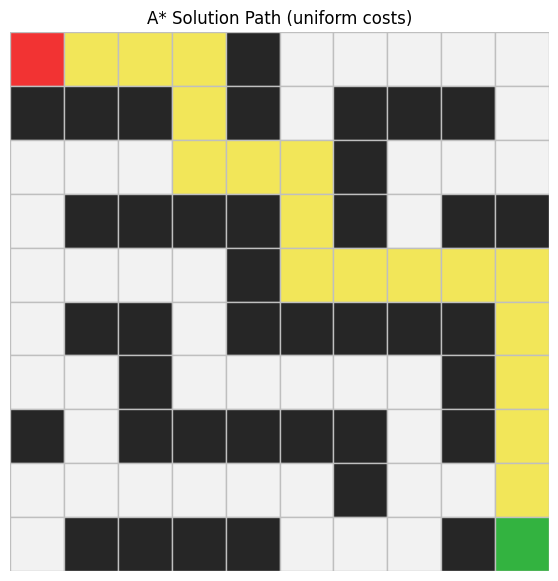

In [186]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

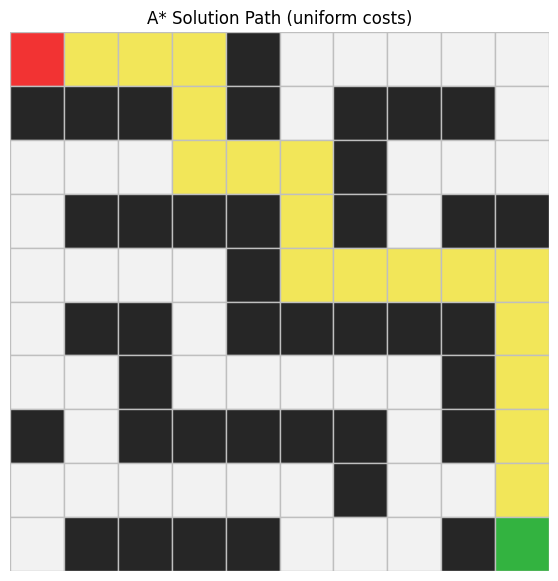

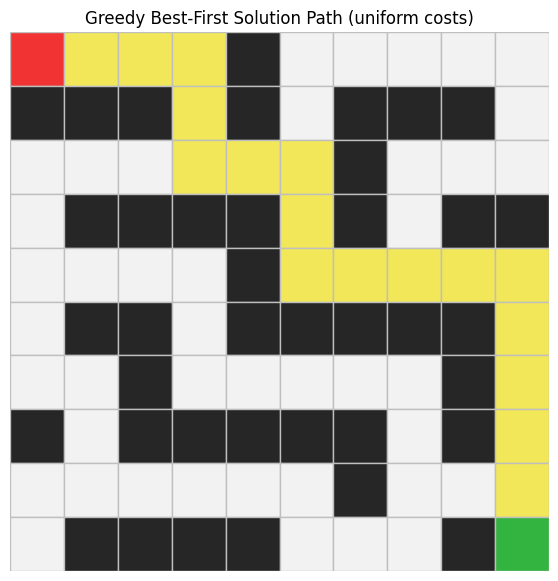

In [187]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

12. The Turbulence Map: Where Greedy Goes Wrong

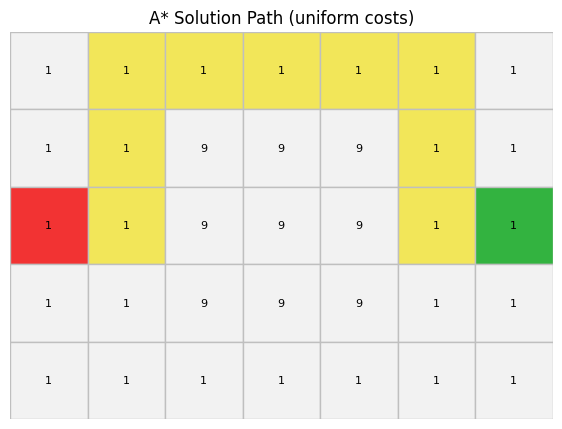

In [188]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A* Solution Path (uniform costs)",
)

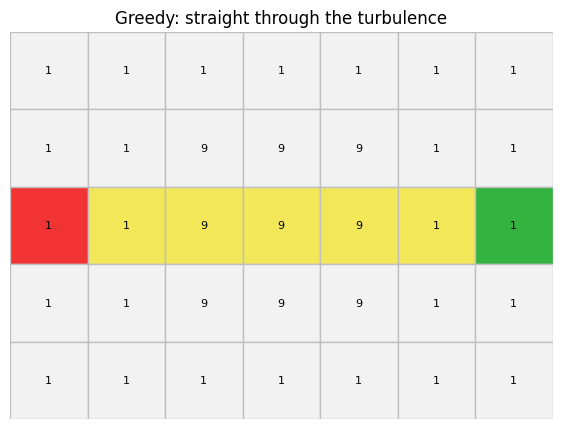

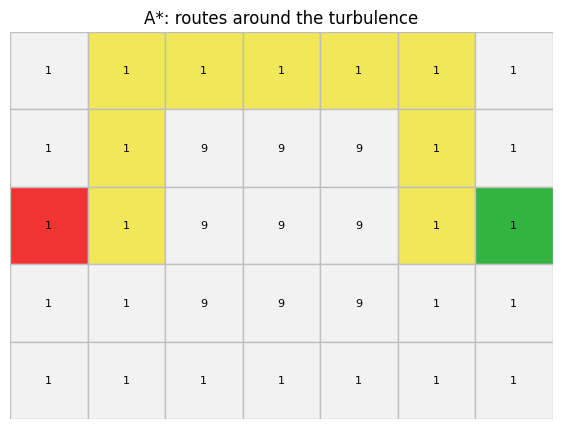

In [189]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

13. Experiment: Breaking Admissibility

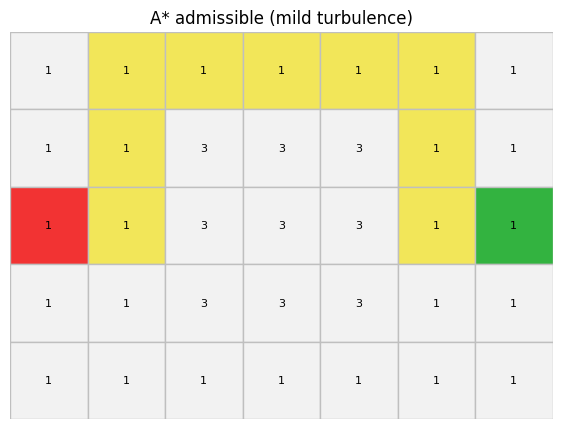

In [190]:
def inflated_heuristic(factor: float):
  def h(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return factor * manhattan_distance(state, goal)
  return h

    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h


mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

plot_path(
    mild_grid,
    (2, 0),
    (2, 6),
    path=experiment_results[2].path,
    terrain_costs=mild_costs,
    title="A* admissible (mild turbulence)",
)

14. Bonus (Optional): Iterative-Deepening A* (IDA*)

In [191]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        initial_node = Node(problem.initial_state())
        limit = self.heuristic(initial_node.state, problem.goal)

        total_expanded = 0
        max_depth = 1
        iteration_log = []

        for iteration in range(1, max_iterations + 1):
          path_set = set()
          result,next_limi
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

15. Create Your Own Maps

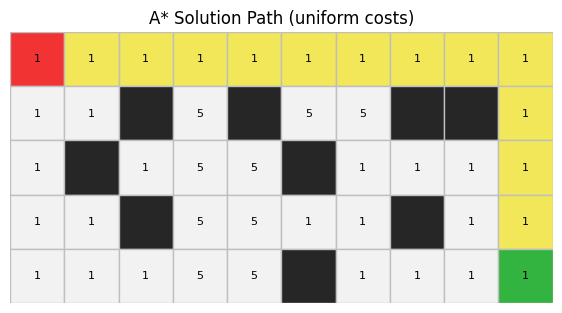

In [192]:
# TODO 10:

custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,0,1,0,0,1,1,0],
    [0,1,0,0,0,1,0,0,0,0],
    [0,0,1,0,0,0,0,1,0,0],
    [0,0,0,0,0,1,0,0,0,0],
]

custom_costs_1 = [
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,5,5,5,5,5,5,1],
    [1,1,1,5,5,1,1,1,1,1],
    [1,1,1,5,5,1,1,1,1,1],
    [1,1,1,5,5,1,1,1,1,1],
]

custom_start_1 = (0,0)
custom_goal_1 = (4,9)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
     ucs.search(custom_problem_1),
     astar.search(custom_problem_1),
     wastar2.search(custom_problem_1),
     greedy.search(custom_problem_1),
 ]

show_results(custom_results_1)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* Solution Path (uniform costs)",
)


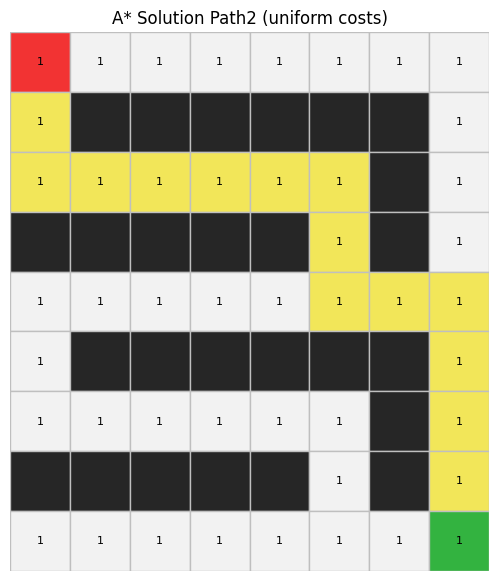

In [193]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 8, 8, 8, 8, 8, 8, 1],
    [1, 1, 1, 1, 1, 1, 8, 1],
    [8, 8, 8, 8, 8, 1, 8, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 8, 8, 8, 8, 8, 8, 1],
    [1, 1, 1, 1, 1, 1, 8, 1],
    [8, 8, 8, 8, 8, 1, 8, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (8, 7)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
     custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
     ucs.search(custom_problem_2),
     astar.search(custom_problem_2),
     wastar2.search(custom_problem_2),
     greedy.search(custom_problem_2),
]
show_results(custom_results_2)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A* Solution Path2 (uniform costs)",
)
#

**16. Reflection Questions**

16.1 Heuristic Functions
1. h(n) estimates how far the drone is from the goal, and the knowledge comes from GPS; we know the coordinates of both the drone and the goal.
2. It removes obstacles and terrain costs. Manhattan assumes no walls exist and every move costs exactly 1.
3. Manhattan dominates Euclidean because it's always larger or equal. This means A* with Manhattan will expand fewer nodes (it's more informed).

4. Manhattan assumes each move costs at least 1. If a move cost 0.5, Manhattan would overestimate the true cost and become inadmissible.


16.2 Greedy Best-First Search
1. Greedy ignores g(n) (cost already paid). On the turbulence map, it flew straight through expensive turbulence (cost 9) because it looked closer to the goal, even though a cheaper path existed around it.
2. Fewer nodes = faster search, but Greedy can find more expensive paths. Better depends on whether you want speed or quality.
3. In an emergency where speed is critical (e.g., delivering medicine before a storm), finding any path quickly is more important than finding the cheapest path.

16.3 A* Search
1. Explain f(n) = g(n) + h(n) in simple words.
 f(n) estimates the total cost from start to goal if the drone goes through node n. It balances what the drone already spent (g) with what it still expects to spend (h).
2.  The first goal found might not be the cheapest. On the turbulence map, Greedy might find a goal through turbulence first, but a cheaper path around it is still waiting. Late goal test prevents returning the wrong solution.
3.  With different terrain costs, a state can be reached via a cheaper path later. A dictionary lets us update the best path. A set would keep the first (possibly more expensive) path.

4. A* expands fewer nodes than UCS. The gap shows how much the heuristic saves computation by guiding the search toward the goal.


16.4 Admissibility and Consistency

1. Define admissible and consistent. Which implies which?

•	Admissible: h(n) never overestimates the true cost (optimistic)

•	Consistent: h(n) =< cost + h(n') (triangle inequality)

•	Consistent implies admissible (but not the other way around)

2. With a heuristic that overestimates (3× Manhattan), A* found a suboptimal (more expensive) path. This proves A* needs an admissible heuristic to guarantee optimality.
3. Yes, Manhattan consistent on a unit-cost grid. For one move, cost = 1 and h decreases by exactly 1, so h(n) = h(n') + 1, which satisfies the triangle inequality.

16.5 Weighted A* and Trade-offs

1. How does W change the algorithm?

•	W = 0 → UCS (f = g)

•	W = 1 → A* (f = g + h)

•	W > 1 → More greedy

•	W → ∞ → Greedy (f = h)

2.  Weighted A  guarantees the solution cost ≤ W × optimal cost.

3. For a drone that has 90 seconds of battery. It should choose Weighted A* with W=2-3. It's faster than A* but still gives a good-quality path.

16.6 Memory and Real-World Drone Context

1. A* stores frontier and reached (O(b^d) memory). IDA* uses depth-first search with f-limits, which uses O(depth) memory but re-expands nodes.

2. Weather, no-fly zones, altitude limits, battery level, wind, and dynamic obstacles.

3. The heuristic becomes wrong because the goal changes. Need real-time replanning.

4. Which algorithm would you ship on the drone?
A* with Manhattan heuristic. If memory is limited, use IDA. If speed is critical, use Weighted A with W=2-3.

